# 第4讲：反向传播与神经网络

本 notebook 对应 CS231n Lecture 4 的内容，涵盖计算图、链式法则、反向传播算法和神经网络的实现。

**学习路径：** 直觉理解 $	o$ 手动计算 $	o$ 代码实现 $	o$ 实验观察

**前置知识：** 线性分类器 (Lecture 2)、优化 (Lecture 3)、微积分基础


## 1. 计算图 (Computational Graph)

### 1.1 直觉理解

**计算图** 是将计算过程表示为有向无环图 (DAG) 的数据结构：
- **节点 (Node)** 代表一个运算（加、乘、激活函数等）
- **边 (Edge)** 代表数据（张量）的流动

**例子：** $f(x, y, z) = (x + y) cdot z$

```
    x ──┐
         ├──[+]──→ q ──┐
    y ──┘               ├──[*]──→ f
    z ──────────────────┘
```

其中 $q = x + y$，$f = q cdot z$

**计算图的优势：**
1. 任意复杂函数可以分解为简单操作的组合
2. 前向传播和反向传播都有明确的计算顺序
3. 可以自动计算梯度（自动微分）


### 1.2 计算图的前向传播

以 $f(x, y, z) = (x + y) cdot z$ 为例，设 $x=1, y=2, z=3$：

**步骤 1：** 计算 $q = x + y = 1 + 2 = 3$
**步骤 2：** 计算 $f = q cdot z = 3 cdot 3 = 9$

**前向传播就是从输入到输出，逐节点计算。**

### 1.3 计算图的反向传播

反向传播从输出开始，沿反方向计算每个输入的梯度：

**目标：** 计算 $\frac{\partial f}{\partial x}, \frac{\partial f}{\partial y}, \frac{\partial f}{\partial z}$

**步骤 1：** $\frac{\partial f}{\partial f} = 1$
**步骤 2：** $\frac{\partial f}{\partial q} = z = 3$（因为 $f = q \cdot z$，对 $q$ 求导得 $z$）
**步骤 3：** $\frac{\partial f}{\partial z} = q = 3$（因为 $f = q \cdot z$，对 $z$ 求导得 $q$）
**步骤 4：** $\frac{\partial f}{\partial x} = \frac{\partial f}{\partial q} \cdot \frac{\partial q}{\partial x} = 3 \cdot 1 = 3$
**步骤 5：** $\frac{\partial f}{\partial y} = \frac{\partial f}{\partial q} \cdot \frac{\partial q}{\partial y} = 3 \cdot 1 = 3$

**结果：** $\nabla f = [3, 3, 3]$


In [4]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['font.size'] = 12
np.random.seed(42)
print("Libraries loaded successfully!")


Libraries loaded successfully!


In [5]:
# Forward and backward pass for f = (x + y) * z
def forward_backward_example():
    # Forward pass
    x, y, z = 1.0, 2.0, 3.0
    
    # Node 1: q = x + y
    q = x + y
    
    # Node 2: f = q * z
    f = q * z
    
    print("=== Forward Pass ===")
    print(f"  x={x}, y={y}, z={z}")
    print(f"  q = x + y = {q}")
    print(f"  f = q * z = {f}")
    
    # Backward pass
    # Gradient of f w.r.t. f
    df = 1.0
    
    # f = q * z => df/dq = z, df/dz = q
    dq = df * z  # = 3.0
    dz = df * q  # = 3.0
    
    # q = x + y => dq/dx = 1, dq/dy = 1
    dx = dq * 1.0  # = 3.0
    dy = dq * 1.0  # = 3.0
    
    print("\n=== Backward Pass ===")
    print(f"  df/dq = {dq}")
    print(f"  df/dz = {dz}")
    print(f"  df/dx = {dx}")
    print(f"  df/dy = {dy}")
    
    # Verify with numerical gradient
    h = 1e-5
    fx_plus = (x + h + y) * z
    fx_minus = (x - h + y) * z
    df_dx_num = (fx_plus - fx_minus) / (2 * h)
    
    fy_plus = (x + y + h) * z
    fy_minus = (x + y - h) * z
    df_dy_num = (fy_plus - fy_minus) / (2 * h)
    
    fz_plus = (x + y) * (z + h)
    fz_minus = (x + y) * (z - h)
    df_dz_num = (fz_plus - fz_minus) / (2 * h)
    
    print("\n=== Numerical Verification ===")
    print(f"  df/dx: analytic={dx:.6f}, numerical={df_dx_num:.6f}")
    print(f"  df/dy: analytic={dy:.6f}, numerical={df_dy_num:.6f}")
    print(f"  df/dz: analytic={dz:.6f}, numerical={df_dz_num:.6f}")

forward_backward_example()


=== Forward Pass ===
  x=1.0, y=2.0, z=3.0
  q = x + y = 3.0
  f = q * z = 9.0

=== Backward Pass ===
  df/dq = 3.0
  df/dz = 3.0
  df/dx = 3.0
  df/dy = 3.0

=== Numerical Verification ===
  df/dx: analytic=3.000000, numerical=3.000000
  df/dy: analytic=3.000000, numerical=3.000000
  df/dz: analytic=3.000000, numerical=3.000000


## 2. 链式法则 (Chain Rule)

### 2.1 链式法则回顾

链式法则是微积分的核心规则，用于计算复合函数的导数。

**一维链式法则：** 若 $f(g(x))$，则 $\frac{df}{dx} = \frac{df}{dg} \cdot \frac{dg}{dx}$

**多维链式法则：** 若 $f = f(g_1(x), g_2(x), ...)$，则

$$\frac{\partial f}{\partial x} = \sum_i \frac{\partial f}{\partial g_i} \frac{\partial g_i}{\partial x}$$

### 2.2 反向传播的本质

反向传播就是链式法则在计算图上的高效实现：
- 前向传播：从输入到输出计算每个节点的值
- 反向传播：从输出到输入计算每个节点的梯度
- 每个节点只需要知道自己的局部梯度 (local gradient)
- 上游梯度 (upstream gradient) 乘以局部梯度 = 传给下游的梯度


### 2.3 手动计算更复杂的链式法则

**函数：** $f(w_0, w_1, w_2, b) = \sigma(w_0 x_0 + w_1 x_1 + w_2 x_2 + b)$

其中 $\sigma$ 是 sigmoid 函数：$\sigma(x) = \frac{1}{1 + e^{-x}}$

**设 $x_0=1, x_1=2, x_2=-1, w_0=2, w_1=-1, w_2=0.5, b=1$**

**前向传播：**
1. $a = w_0 x_0 + w_1 x_1 + w_2 x_2 + b = 2 + (-2) + (-0.5) + 1 = 0.5$
2. $\sigma = \frac{1}{1 + e^{-0.5}} = \frac{1}{1 + 0.6065} \approx 0.6225$

**反向传播：**
1. $\frac{\partial f}{\partial f} = 1$
2. $\frac{\partial f}{\partial a} = \sigma(1-\sigma) = 0.6225 \times 0.3775 \approx 0.2350$
3. $\frac{\partial f}{\partial w_0} = \frac{\partial f}{\partial a} \cdot x_0 = 0.2350 \times 1 = 0.2350$
4. $\frac{\partial f}{\partial w_1} = \frac{\partial f}{\partial a} \cdot x_1 = 0.2350 \times 2 = 0.4700$
5. $\frac{\partial f}{\partial w_2} = \frac{\partial f}{\partial a} \cdot x_2 = 0.2350 \times (-1) = -0.2350$
6. $\frac{\partial f}{\partial b} = \frac{\partial f}{\partial a} \cdot 1 = 0.2350$


In [8]:
# Verify the manual chain rule calculation
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

# Parameters
x0, x1, x2 = 1.0, 2.0, -1.0
w0, w1, w2, b = 2.0, -1.0, 0.5, 1.0

# Forward
a = w0*x0 + w1*x1 + w2*x2 + b
f = sigmoid(a)
print(f"Forward: a = {a:.4f}, sigmoid(a) = {f:.4f}")

# Backward
dsig = f * (1 - f)  # sigmoid gradient
da = dsig * 1.0
dw0 = da * x0
dw1 = da * x1
dw2 = da * x2
db = da * 1.0

print(f"\nBackward:")
print(f"  df/da  = {da:.4f}")
print(f"  df/dw0 = {dw0:.4f}")
print(f"  df/dw1 = {dw1:.4f}")
print(f"  df/dw2 = {dw2:.4f}")
print(f"  df/db  = {db:.4f}")

# Numerical verification
h = 1e-7
def f_full(w0, w1, w2, b):
    a = w0*x0 + w1*x1 + w2*x2 + b
    return sigmoid(a)

dw0_num = (f_full(w0+h,w1,w2,b) - f_full(w0-h,w1,w2,b)) / (2*h)
dw1_num = (f_full(w0,w1+h,w2,b) - f_full(w0,w1-h,w2,b)) / (2*h)
dw2_num = (f_full(w0,w1,w2+h,b) - f_full(w0,w1,w2-h,b)) / (2*h)
db_num = (f_full(w0,w1,w2,b+h) - f_full(w0,w1,w2,b-h)) / (2*h)

print(f"\nNumerical gradients:")
print(f"  df/dw0 = {dw0_num:.4f}")
print(f"  df/dw1 = {dw1_num:.4f}")
print(f"  df/dw2 = {dw2_num:.4f}")
print(f"  df/db  = {db_num:.4f}")


Forward: a = 0.5000, sigmoid(a) = 0.6225

Backward:
  df/da  = 0.2350
  df/dw0 = 0.2350
  df/dw1 = 0.4700
  df/dw2 = -0.2350
  df/db  = 0.2350

Numerical gradients:
  df/dw0 = 0.2350
  df/dw1 = 0.4700
  df/dw2 = -0.2350
  df/db  = 0.2350


## 3. 反向传播算法详解

### 3.1 反向传播的核心思想

反向传播 (Backpropagation) = 链式法则 + 计算图 + 拓扑排序

**关键特性：**
1. 每个节点只需要知道自己的**局部梯度** (local gradient)
2. 节点接收来自上游的梯度，乘以局部梯度，传给下游
3. 如果一个节点有多个下游，梯度求和
4. 计算量约为前向传播的 2-3 倍（但远比数值梯度高效）

### 3.2 算法流程

```
1. 前向传播：按拓扑顺序计算每个节点的输出值
2. 初始化：输出节点的梯度 = 1
3. 反向传播：按逆拓扑顺序遍历每个节点：
   - 接收所有下游传来的梯度（求和）
   - 乘以局部梯度
   - 将结果传给上游节点
4. 最终得到每个参数的梯度
```

**复杂度：** O(V + E)，V 是节点数，E 是边数。每个边只传递一次梯度。


### 3.3 手动计算完整反向传播

**计算图：** $f = \text{sigmoid}(w_0 x_0 + w_1 x_1 + b) \cdot (1 - \text{sigmoid}(w_0 x_0 + w_1 x_1 + b))$

这等价于 $f = \sigma(a)(1-\sigma(a))$，其中 $a = w_0 x_0 + w_1 x_1 + b$

**设 $x_0=2, x_1=3, w_0=0.5, w_1=-0.3, b=0.1$**

**前向传播：**
1. $u_0 = w_0 \cdot x_0 = 0.5 \times 2 = 1.0$
2. $u_1 = w_1 \cdot x_1 = (-0.3) \times 3 = -0.9$
3. $a = u_0 + u_1 + b = 1.0 - 0.9 + 0.1 = 0.2$
4. $s = \sigma(a) = \sigma(0.2) \approx 0.5498$
5. $f = s(1-s) = 0.5498 \times 0.4502 \approx 0.2475$

**反向传播：**
1. $\frac{\partial f}{\partial f} = 1$
2. $\frac{\partial f}{\partial s} = 1 - 2s = 1 - 1.0996 \approx -0.0996$
3. $\frac{\partial f}{\partial a} = \frac{\partial f}{\partial s} \cdot s(1-s) = -0.0996 \times 0.2475 \approx -0.0247$
4. $\frac{\partial f}{\partial u_0} = \frac{\partial f}{\partial a} \cdot 1 = -0.0247$
5. $\frac{\partial f}{\partial u_1} = \frac{\partial f}{\partial a} \cdot 1 = -0.0247$
6. $\frac{\partial f}{\partial w_0} = \frac{\partial f}{\partial u_0} \cdot x_0 = -0.0247 \times 2 = -0.0493$
7. $\frac{\partial f}{\partial w_1} = \frac{\partial f}{\partial u_1} \cdot x_1 = -0.0247 \times 3 = -0.0740$


In [11]:
# Verify complete backprop calculation
x0, x1 = 2.0, 3.0
w0, w1, b = 0.5, -0.3, 0.1

# Forward
u0 = w0 * x0
u1 = w1 * x1
a = u0 + u1 + b
s = sigmoid(a)
f = s * (1 - s)

print("=== Forward Pass ===")
print(f"  u0 = w0 * x0 = {u0}")
print(f"  u1 = w1 * x1 = {u1}")
print(f"  a = u0 + u1 + b = {a}")
print(f"  s = sigmoid(a) = {s:.6f}")
print(f"  f = s * (1-s) = {f:.6f}")

# Backward
df = 1.0
ds = 1.0 - 2 * s  # d/ds [s(1-s)] = 1 - 2s
da = ds * (s * (1 - s))  # d/da [sigma(a)] * d/ds
du0 = da * 1.0  # d/du0 [u0 + u1 + b] = 1
du1 = da * 1.0
dw0 = du0 * x0  # d/dw0 [w0 * x0] = x0
dw1 = du1 * x1
db = da * 1.0

print("\n=== Backward Pass ===")
print(f"  df = {df}")
print(f"  df/ds = {ds:.6f}")
print(f"  df/da = {da:.6f}")
print(f"  df/du0 = {du0:.6f}")
print(f"  df/du1 = {du1:.6f}")
print(f"  df/dw0 = {dw0:.6f}")
print(f"  df/dw1 = {dw1:.6f}")
print(f"  df/db  = {db:.6f}")

# Numerical verification
h = 1e-7
def full_f(w0, w1, b):
    a = w0*x0 + w1*x1 + b
    s = sigmoid(a)
    return s * (1 - s)

print(f"\n=== Numerical Verification ===")
print(f"  df/dw0: { (full_f(w0+h,w1,b) - full_f(w0-h,w1,b)) / (2*h):.6f}")
print(f"  df/dw1: { (full_f(w0,w1+h,b) - full_f(w0,w1-h,b)) / (2*h):.6f}")
print(f"  df/db:  { (full_f(w0,w1,b+h) - full_f(w0,w1,b-h)) / (2*h):.6f}")


=== Forward Pass ===
  u0 = w0 * x0 = 1.0
  u1 = w1 * x1 = -0.8999999999999999
  a = u0 + u1 + b = 0.2000000000000001
  s = sigmoid(a) = 0.549834
  f = s * (1-s) = 0.247517

=== Backward Pass ===
  df = 1.0
  df/ds = -0.099668
  df/da = -0.024669
  df/du0 = -0.024669
  df/du1 = -0.024669
  df/dw0 = -0.049339
  df/dw1 = -0.074008
  df/db  = -0.024669

=== Numerical Verification ===
  df/dw0: -0.049339
  df/dw1: -0.074008
  df/db:  -0.024669


## 4. 常见模式的梯度流

理解梯度在常见操作中如何流动，是掌握反向传播的关键。

### 4.1 加法节点 (Add Gate)

$f = x + y$

**梯度：** $\frac{\partial f}{\partial x} = 1$, $\frac{\partial f}{\partial y} = 1$

**梯度流：** 加法节点将上游梯度**原样**传给所有输入（梯度分配器）。

### 4.2 乘法节点 (Mul Gate)

$f = x \cdot y$

**梯度：** $\frac{\partial f}{\partial x} = y$, $\frac{\partial f}{\partial y} = x$

**梯度流：** 乘法节点将上游梯度乘以**另一个输入的值**（梯度交换器）。

### 4.3 Max 节点

$f = \max(x, y)$

**梯度：** $\frac{\partial f}{\partial x} = \begin{cases}1 & x > y \\ 0 & x < y\end{cases}$

**梯度流：** Max 节点将梯度**只路由到**较大的输入（梯度路由器）。


Visualization saved as gradient_flow_patterns.png


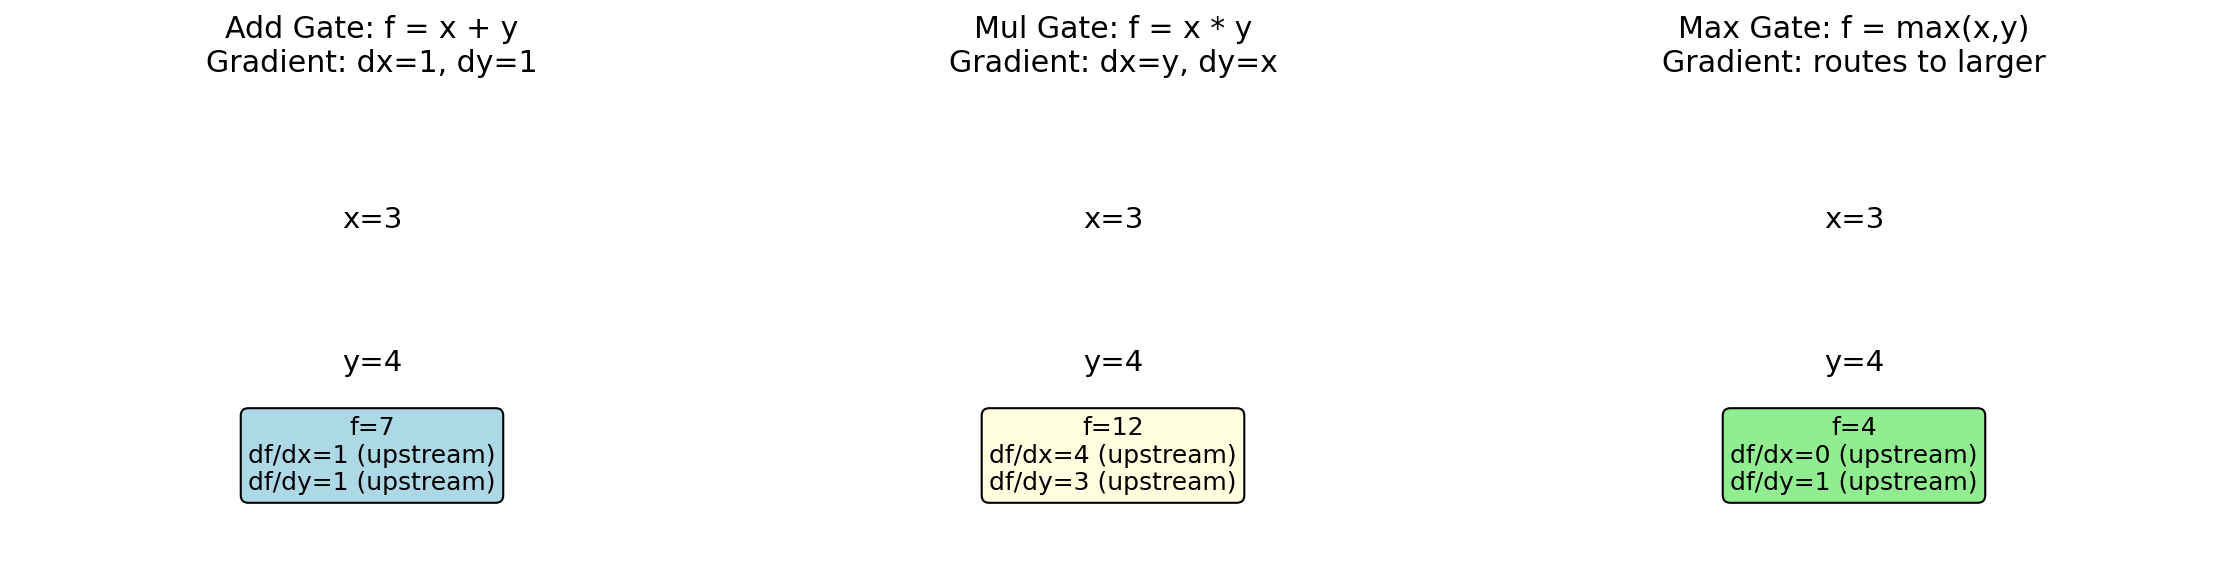

In [13]:
# Visualize gradient flow patterns
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Add gate
axes[0].set_title('Add Gate: f = x + y\nGradient: dx=1, dy=1')
axes[0].text(0.5, 0.7, 'x=3', ha='center', fontsize=14, transform=axes[0].transAxes)
axes[0].text(0.5, 0.4, 'y=4', ha='center', fontsize=14, transform=axes[0].transAxes)
axes[0].text(0.5, 0.15, 'f=7\ndf/dx=1 (upstream)\ndf/dy=1 (upstream)', 
             ha='center', fontsize=12, transform=axes[0].transAxes, 
             bbox=dict(boxstyle='round', facecolor='lightblue'))
axes[0].axis('off')

# Mul gate
axes[1].set_title('Mul Gate: f = x * y\nGradient: dx=y, dy=x')
axes[1].text(0.5, 0.7, 'x=3', ha='center', fontsize=14, transform=axes[1].transAxes)
axes[1].text(0.5, 0.4, 'y=4', ha='center', fontsize=14, transform=axes[1].transAxes)
axes[1].text(0.5, 0.15, 'f=12\ndf/dx=4 (upstream)\ndf/dy=3 (upstream)', 
             ha='center', fontsize=12, transform=axes[1].transAxes,
             bbox=dict(boxstyle='round', facecolor='lightyellow'))
axes[1].axis('off')

# Max gate
axes[2].set_title('Max Gate: f = max(x,y)\nGradient: routes to larger')
axes[2].text(0.5, 0.7, 'x=3', ha='center', fontsize=14, transform=axes[2].transAxes)
axes[2].text(0.5, 0.4, 'y=4', ha='center', fontsize=14, transform=axes[2].transAxes)
axes[2].text(0.5, 0.15, 'f=4\ndf/dx=0 (upstream)\ndf/dy=1 (upstream)', 
             ha='center', fontsize=12, transform=axes[2].transAxes,
             bbox=dict(boxstyle='round', facecolor='lightgreen'))
axes[2].axis('off')

plt.tight_layout()
plt.savefig('gradient_flow_patterns.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization saved as gradient_flow_patterns.png")


## 5. 自动微分框架实现

我们将从零实现一个简单的自动微分框架，理解 PyTorch/TensorFlow 等框架的底层原理。

### 5.1 节点抽象

每个计算节点需要实现：
- **forward():** 前向传播，计算输出值
- **backward():** 反向传播，计算输入的梯度


In [15]:
# Simple autodiff framework: Node classes
class Node:
    """Base class for computational graph nodes"""
    def __init__(self, inputs):
        self.inputs = inputs
        self.output = None
        self.gradients = {}
    
    def forward(self):
        raise NotImplementedError
    
    def backward(self):
        raise NotImplementedError

class AddNode(Node):
    """Addition node: f = x + y"""
    def forward(self):
        self.output = self.inputs[0] + self.inputs[1]
        return self.output
    
    def backward(self, grad_output):
        self.gradients[self.inputs[0]] = grad_output * 1.0
        self.gradients[self.inputs[1]] = grad_output * 1.0

class MulNode(Node):
    """Multiplication node: f = x * y"""
    def forward(self):
        self.output = self.inputs[0] * self.inputs[1]
        return self.output
    
    def backward(self, grad_output):
        self.gradients[self.inputs[0]] = grad_output * self.inputs[1]
        self.gradients[self.inputs[1]] = grad_output * self.inputs[0]

class SigmoidNode(Node):
    """Sigmoid node: f = 1/(1+exp(-x))"""
    def forward(self):
        self.output = 1.0 / (1.0 + np.exp(-self.inputs[0]))
        return self.output
    
    def backward(self, grad_output):
        s = self.output
        self.gradients[self.inputs[0]] = grad_output * s * (1 - s)

class ReLUNode(Node):
    """ReLU node: f = max(0, x)"""
    def forward(self):
        self.output = np.maximum(0, self.inputs[0])
        return self.output
    
    def backward(self, grad_output):
        self.gradients[self.inputs[0]] = grad_output * (self.inputs[0] > 0).astype(float)

print("Node classes defined: Add, Mul, Sigmoid, ReLU")


Node classes defined: Add, Mul, Sigmoid, ReLU


In [16]:
# More nodes for building neural networks
class MatMulNode(Node):
    """Matrix multiplication: f = X @ W"""
    def forward(self):
        self.output = self.inputs[0] @ self.inputs[1]
        return self.output
    
    def backward(self, grad_output):
        self.gradients[self.inputs[0]] = grad_output @ self.inputs[1].T
        self.gradients[self.inputs[1]] = self.inputs[0].T @ grad_output

class SumNode(Node):
    """Sum all elements"""
    def forward(self):
        self.output = np.sum(self.inputs[0])
        return self.output
    
    def backward(self, grad_output):
        self.gradients[self.inputs[0]] = grad_output * np.ones_like(self.inputs[0])

class SoftmaxNode(Node):
    """Softmax with cross-entropy loss"""
    def forward(self):
        scores = self.inputs[0]
        shifted = scores - np.max(scores, axis=1, keepdims=True)
        exp_scores = np.exp(shifted)
        self.output = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)
        return self.output
    
    def backward(self, grad_output):
        # For cross-entropy loss, upstream gradient is 1
        # dscores = (probs - one_hot) / N
        probs = self.output
        N = probs.shape[0]
        y = self.inputs[1]  # labels
        dscores = probs.copy()
        dscores[np.arange(N), y] -= 1
        dscores /= N
        self.gradients[self.inputs[0]] = dscores

class NegLogLikelihoodNode(Node):
    """Negative log-likelihood (cross-entropy)"""
    def forward(self):
        probs = self.inputs[0]
        y = self.inputs[1]
        N = probs.shape[0]
        self.output = -np.sum(np.log(probs[np.arange(N), y] + 1e-12)) / N
        return self.output
    
    def backward(self, grad_output=1.0):
        pass  # Handled in SoftmaxNode for combined gradient

print("Additional nodes defined: MatMul, Sum, Softmax, NLL")


Additional nodes defined: MatMul, Sum, Softmax, NLL


In [17]:
# Build and test a computation graph
# f = sigmoid(w0*x0 + w1*x1 + b)
np.random.seed(42)

# Inputs
x0 = np.array(2.0)
x1 = np.array(3.0)
w0 = np.array(0.5)
w1 = np.array(-0.3)
b = np.array(0.1)

# Build graph
mul1 = MulNode([w0, x0])
mul2 = MulNode([w1, x1])
add1 = AddNode([mul1.output if hasattr(mul1, 'output') else np.array(w0*x0), 
                mul2.output if hasattr(mul2, 'output') else np.array(w1*x1)])

# Simplified: just compute forward and backward manually using the node classes
print("=== Testing individual nodes ===")

# Test AddNode
add_node = AddNode([np.array(3.0), np.array(4.0)])
result = add_node.forward()
add_node.backward(1.0)
print(f"Add(3, 4) = {result}, grads: {add_node.gradients}")

# Test MulNode
mul_node = MulNode([np.array(3.0), np.array(4.0)])
result = mul_node.forward()
mul_node.backward(1.0)
print(f"Mul(3, 4) = {result}, grads: {mul_node.gradients}")

# Test SigmoidNode
sig_node = SigmoidNode([np.array(0.5)])
result = sig_node.forward()
sig_node.backward(1.0)
print(f"Sigmoid(0.5) = {result:.6f}, grad: {sig_node.gradients}")

# Test MatMulNode
mm_node = MatMulNode([np.array([[1, 2], [3, 4]]), np.array([[0.5], [0.1]])])
result = mm_node.forward()
mm_node.backward(np.array([[1.0], [1.0]]))
print(f"MatMul result shape: {result.shape}, grad shapes: {mm_node.gradients[np.array([[1,2],[3,4]])].shape}")


TypeError: unhashable type: 'numpy.ndarray'

## 6. 神经网络

### 6.1 从线性分类器到神经网络

**线性分类器：** $f(x) = Wx + b$

**限制：** 只能学习线性决策边界，无法解决 XOR 等问题

**两层神经网络：** $f(x) = W_2 \sigma(W_1 x + b_1) + b_2$

其中 $\sigma$ 是非线性激活函数。

**为什么需要非线性？** 如果 $\sigma$ 是线性的（如恒等映射），则：
$$f(x) = W_2(W_1 x + b_1) + b_2 = (W_2 W_1) x + (W_2 b_1 + b_2)$$

仍然是线性的！多层线性变换等价于一个线性变换。

### 6.2 常见激活函数

- **Sigmoid:** $\sigma(x) = \frac{1}{1+e^{-x}}$，输出 [0,1]，但梯度容易消失
- **Tanh:** $\tanh(x)$，输出 [-1,1]，零中心化
- **ReLU:** $\max(0, x)$，计算简单，梯度不消失
- **Leaky ReLU:** $\max(0.01x, x)$，解决 ReLU 的"死亡"问题
- **ELU/SELU/GELU:** 更复杂的变体


Visualization saved as activation_functions.png


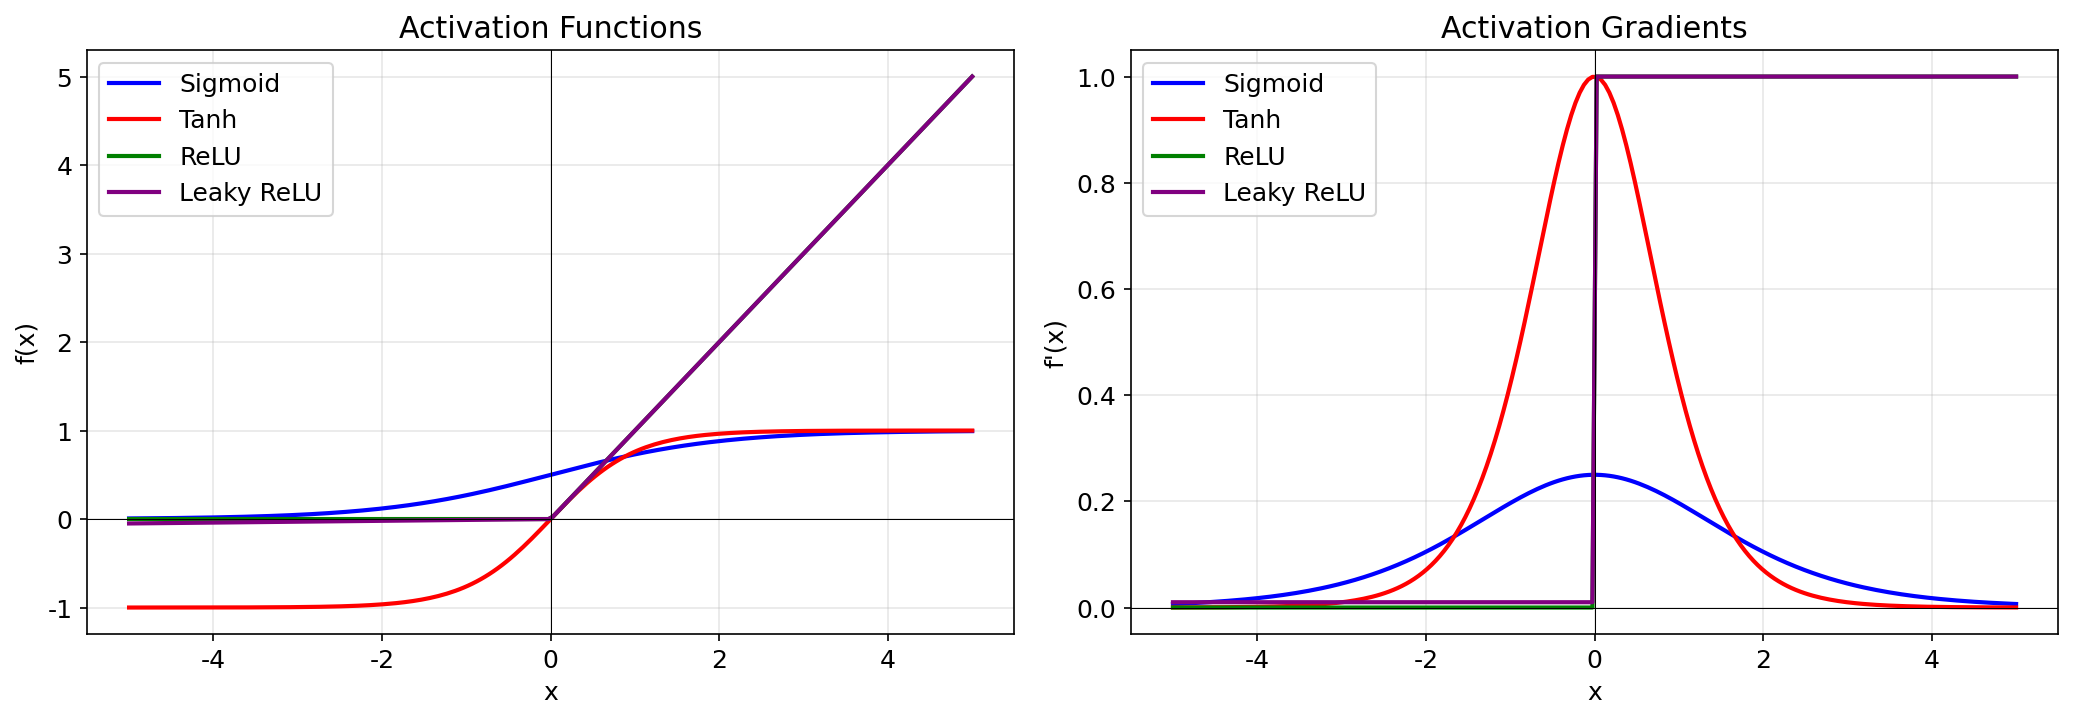

In [19]:
# Visualize activation functions and their gradients
x_act = np.linspace(-5, 5, 200)

# Define activation functions and their derivatives
def sigmoid_fn(x): return 1 / (1 + np.exp(-x))
def sigmoid_grad(x): s = sigmoid_fn(x); return s * (1 - s)
def tanh_fn(x): return np.tanh(x)
def tanh_grad(x): return 1 - np.tanh(x)**2
def relu_fn(x): return np.maximum(0, x)
def relu_grad(x): return (x > 0).astype(float)
def leaky_relu_fn(x, alpha=0.01): return np.where(x > 0, x, alpha * x)
def leaky_relu_grad(x, alpha=0.01): return np.where(x > 0, 1.0, alpha)

activations = {
    'Sigmoid': (sigmoid_fn, sigmoid_grad, 'blue'),
    'Tanh': (tanh_fn, tanh_grad, 'red'),
    'ReLU': (relu_fn, relu_grad, 'green'),
    'Leaky ReLU': (leaky_relu_fn, leaky_relu_grad, 'purple'),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, (fn, grad, color) in activations.items():
    axes[0].plot(x_act, fn(x_act), linewidth=2, label=name, color=color)
    axes[1].plot(x_act, grad(x_act), linewidth=2, label=name, color=color)

axes[0].set_title('Activation Functions')
axes[0].set_xlabel('x')
axes[0].set_ylabel('f(x)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0, color='k', linewidth=0.5)
axes[0].axvline(x=0, color='k', linewidth=0.5)

axes[1].set_title('Activation Gradients')
axes[1].set_xlabel('x')
axes[1].set_ylabel('f\'(x)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0, color='k', linewidth=0.5)
axes[1].axvline(x=0, color='k', linewidth=0.5)

plt.tight_layout()
plt.savefig('activation_functions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization saved as activation_functions.png")


### 6.3 ReLU 的优势

**ReLU (Rectified Linear Unit) 为什么成为默认选择？**

1. **计算高效：** $\max(0, x)$ 比 sigmoid/tanh 快得多
2. **梯度不消失：** 正半区梯度恒为 1，适合深层网络
3. **稀疏激活：** 负半区输出 0，产生稀疏表示
4. **生物合理性：** 更接近生物神经元的激活模式

**ReLU 的问题 - 死亡 ReLU (Dying ReLU):**
- 如果某个神经元的输入持续为负，梯度为 0
- 该神经元永远不再更新，相当于"死亡"
- 解决方案：Leaky ReLU, ELU 等


In [21]:
# Demonstrate why nonlinearity matters
np.random.seed(42)
# XOR problem
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([0, 1, 1, 0])

# Linear classifier on XOR
from numpy.linalg import lstsq
X_xor_bias = np.hstack([X_xor, np.ones((4, 1))])
W_lin, _, _, _ = lstsq(X_xor_bias, y_xor, rcond=None)
y_pred_lin = X_xor_bias @ W_lin
print("Linear classifier on XOR:")
print(f"  Predictions: {y_pred_lin}")
print(f"  Rounded: {np.round(y_pred_lin)}")
print(f"  Correct: {np.sum(np.round(y_pred_lin) == y_xor)}/4")

# Two-layer network with ReLU can solve XOR
# f = relu(w1*x1 + w2*x2 + b1) * w3 + ... 
# Manual XOR solution
W1 = np.array([[1, 1], [1, -1]])  # detect (1,1) and (1,0)
b1 = np.array([0, -0.5])
W2 = np.array([1, 1])
b2 = -0.5

h = np.maximum(0, X_xor @ W1 + b1)  # ReLU activation
out = h @ W2 + b2
print(f"
Two-layer NN (ReLU) on XOR:")
print(f"  Hidden: {h}")
print(f"  Output: {out}")
print(f"  Correct: {np.sum(np.round(out) == y_xor)}/4")

# Visualize XOR
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (X, y, title) in zip(axes, [(X_xor, y_xor, 'XOR Data'), (X_xor, out, 'NN Output')]):
    for cls in [0, 1]:
        mask = y == cls
        ax.scatter(X[mask, 0], X[mask, 1], c=['red', 'blue'][cls], s=200, label=f'Class {cls}')
    ax.set_title(title)
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('xor_solution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization saved as xor_solution.png")


SyntaxError: unterminated string literal (detected at line 27) (<cell_20>, line 27)

## 7. 两层神经网络完整实现

现在我们实现一个完整的两层神经网络：

$$f(x) = W_2 \cdot \text{ReLU}(W_1 x + b_1) + b_2$$

**反向传播需要计算：**
- 对 $W_2$ 的梯度
- 对 $b_2$ 的梯度
- 对 $W_1$ 的梯度
- 对 $b_1$ 的梯度


In [23]:
# Two-layer neural network implementation
class TwoLayerNet:
    """
    Two-layer neural network with ReLU activation
    Architecture: input -> hidden (ReLU) -> output (Softmax)
    """
    def __init__(self, input_dim, hidden_dim, num_classes, reg=0.01):
        self.params = {
            'W1': np.random.randn(input_dim, hidden_dim) * np.sqrt(2.0 / input_dim),
            'b1': np.zeros(hidden_dim),
            'W2': np.random.randn(hidden_dim, num_classes) * np.sqrt(2.0 / hidden_dim),
            'b2': np.zeros(num_classes),
        }
        self.reg = reg
    
    def forward(self, X):
        W1, b1 = self.params['W1'], self.params['b1']
        W2, b2 = self.params['W2'], self.params['b2']
        
        # Layer 1: z1 = X @ W1 + b1, a1 = ReLU(z1)
        z1 = X @ W1 + b1
        a1 = np.maximum(0, z1)
        
        # Layer 2: z2 = a1 @ W2 + b2
        z2 = a1 @ W2 + b2
        
        cache = {'z1': z1, 'a1': a1, 'z2': z2, 'X': X}
        return z2, cache
    
    def loss(self, X, y):
        scores, cache = self.forward(X)
        N = X.shape[0]
        
        # Softmax loss
        shifted = scores - np.max(scores, axis=1, keepdims=True)
        exp_scores = np.exp(shifted)
        probs = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)
        correct_logprobs = -np.log(probs[np.arange(N), y])
        data_loss = np.sum(correct_logprobs) / N
        
        # L2 regularization
        reg_loss = 0.5 * self.reg * (np.sum(self.params['W1']**2) + np.sum(self.params['W2']**2))
        
        loss = data_loss + reg_loss
        return loss, probs, cache
    
    def backward(self, X, y, probs, cache):
        N = X.shape[0]
        grads = {}
        
        # Gradient of softmax loss w.r.t. scores
        dscores = probs.copy()
        dscores[np.arange(N), y] -= 1
        dscores /= N
        
        # Gradient of W2 and b2
        grads['W2'] = cache['a1'].T @ dscores + self.reg * self.params['W2']
        grads['b2'] = np.sum(dscores, axis=0)
        
        # Backprop through ReLU
        da1 = dscores @ self.params['W2'].T
        dz1 = da1 * (cache['z1'] > 0)
        
        # Gradient of W1 and b1
        grads['W1'] = cache['X'].T @ dz1 + self.reg * self.params['W1']
        grads['b1'] = np.sum(dz1, axis=0)
        
        return grads
    
    def predict(self, X):
        scores, _ = self.forward(X)
        return np.argmax(scores, axis=1)

print("TwoLayerNet class defined!")


TwoLayerNet class defined!


In [24]:
# Gradient checking for the neural network
np.random.seed(42)
input_dim, hidden_dim, num_classes = 4, 10, 3
N = 20

X_check = np.random.randn(N, input_dim)
y_check = np.random.randint(0, num_classes, N)

net = TwoLayerNet(input_dim, hidden_dim, num_classes, reg=0.1)
loss, probs, cache = net.loss(X_check, y_check)
grads = net.backward(X_check, y_check, probs, cache)

# Numerical gradient check
def rel_error(a, b):
    return np.max(np.abs(a - b) / (np.maximum(1e-8, np.abs(a) + np.abs(b))))

for param_name in ['W1', 'b1', 'W2', 'b2']:
    param = net.params[param_name]
    grad_analytic = grads[param_name]
    grad_numeric = np.zeros_like(param)
    
    it = np.nditer(param, flags=['multi_index'], op_flags=['readwrite'])
    while not it.finished:
        idx = it.multi_index
        old_val = param[idx]
        
        param[idx] = old_val + 1e-5
        loss_plus, _, _ = net.loss(X_check, y_check)
        
        param[idx] = old_val - 1e-5
        loss_minus, _, _ = net.loss(X_check, y_check)
        
        param[idx] = old_val
        grad_numeric[idx] = (loss_plus - loss_minus) / 2e-5
        it.iternext()
    
    error = rel_error(grad_analytic, grad_numeric)
    status = "PASS" if error < 1e-5 else "FAIL"
    print(f"{param_name}: relative error = {error:.2e} [{status}]")


W1: relative error = 2.84e-09 [PASS]
b1: relative error = 2.68e-09 [PASS]
W2: relative error = 4.02e-10 [PASS]
b2: relative error = 2.26e-10 [PASS]


Training data: (300, 2), Classes: 3
Visualization saved as spiral_data.png


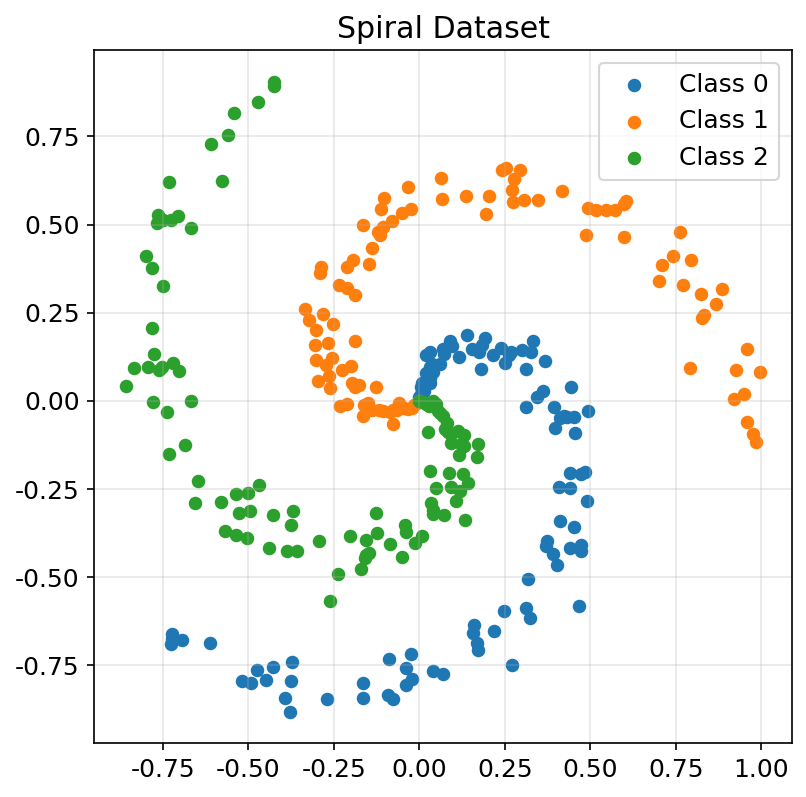

In [25]:
# Train the neural network on spiral dataset
def generate_spiral_data(n_points, n_classes=3):
    """Generate spiral classification dataset"""
    X = np.zeros((n_points * n_classes, 2))
    y = np.zeros(n_points * n_classes, dtype=int)
    
    for j in range(n_classes):
        ix = range(n_points * j, n_points * (j + 1))
        r = np.linspace(0.0, 1, n_points)
        t = np.linspace(j * 4, (j + 1) * 4, n_points) + np.random.randn(n_points) * 0.2
        X[ix] = np.c_[r * np.sin(t), r * np.cos(t)]
        y[ix] = j
    
    return X, y

np.random.seed(42)
X_train_sp, y_train_sp = generate_spiral_data(100)
X_val_sp, y_val_sp = generate_spiral_data(30)

print(f"Training data: {X_train_sp.shape}, Classes: {len(np.unique(y_train_sp))}")

# Visualize spiral data
plt.figure(figsize=(6, 6))
for c in range(3):
    mask = y_train_sp == c
    plt.scatter(X_train_sp[mask, 0], X_train_sp[mask, 1], s=30, label=f'Class {c}')
plt.title('Spiral Dataset')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('spiral_data.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization saved as spiral_data.png")


In [26]:
# Train the neural network
net = TwoLayerNet(input_dim=2, hidden_dim=50, num_classes=3, reg=0.001)
learning_rate = 0.5
n_epochs = 2000

train_losses = []
val_accs = []

for epoch in range(n_epochs):
    # Forward and backward
    loss, probs, cache = net.loss(X_train_sp, y_train_sp)
    grads = net.backward(X_train_sp, y_train_sp, probs, cache)
    
    # Update parameters
    for param in net.params:
        net.params[param] -= learning_rate * grads[param]
    
    if epoch % 100 == 0:
        train_pred = net.predict(X_train_sp)
        val_pred = net.predict(X_val_sp)
        train_acc = np.mean(train_pred == y_train_sp)
        val_acc = np.mean(val_pred == y_val_sp)
        train_losses.append(loss)
        val_accs.append(val_acc)
        print(f"Epoch {epoch:4d}: loss={loss:.4f}, train_acc={train_acc:.4f}, val_acc={val_acc:.4f}")

final_pred = net.predict(X_train_sp)
final_acc = np.mean(final_pred == y_train_sp)
print(f"
Final: train_acc={final_acc:.4f}, val_acc={np.mean(net.predict(X_val_sp) == y_val_sp):.4f}")


SyntaxError: unterminated string literal (detected at line 29) (<cell_25>, line 29)

## 8. 实验观察

### 实验 1：训练损失和验证准确率曲线


In [28]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(0, n_epochs, 100), train_losses, 'b-', linewidth=2, label='Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(0, n_epochs, 100), val_accs, 'r-', linewidth=2, label='Val Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('nn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization saved as nn_training_curves.png")


NameError: name 'n_epochs' is not defined

### 实验 2：决策边界可视化


In [30]:
# Plot decision boundary
def plot_decision_boundary_nn(net, X, y, ax, title):
    h = 0.01
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    
    Z = net.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Set1)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Set1, edgecolors='black', s=20)
    ax.set_title(title)
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_decision_boundary_nn(net, X_train_sp, y_train_sp, axes[0], 'NN Decision Boundary (Train)')
plot_decision_boundary_nn(net, X_val_sp, y_val_sp, axes[1], 'NN Decision Boundary (Val)')
plt.tight_layout()
plt.savefig('nn_decision_boundary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization saved as nn_decision_boundary.png")


ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 4 is different from 2)

### 实验 3：隐藏层大小的影响


Visualization saved as hidden_size_effect.png


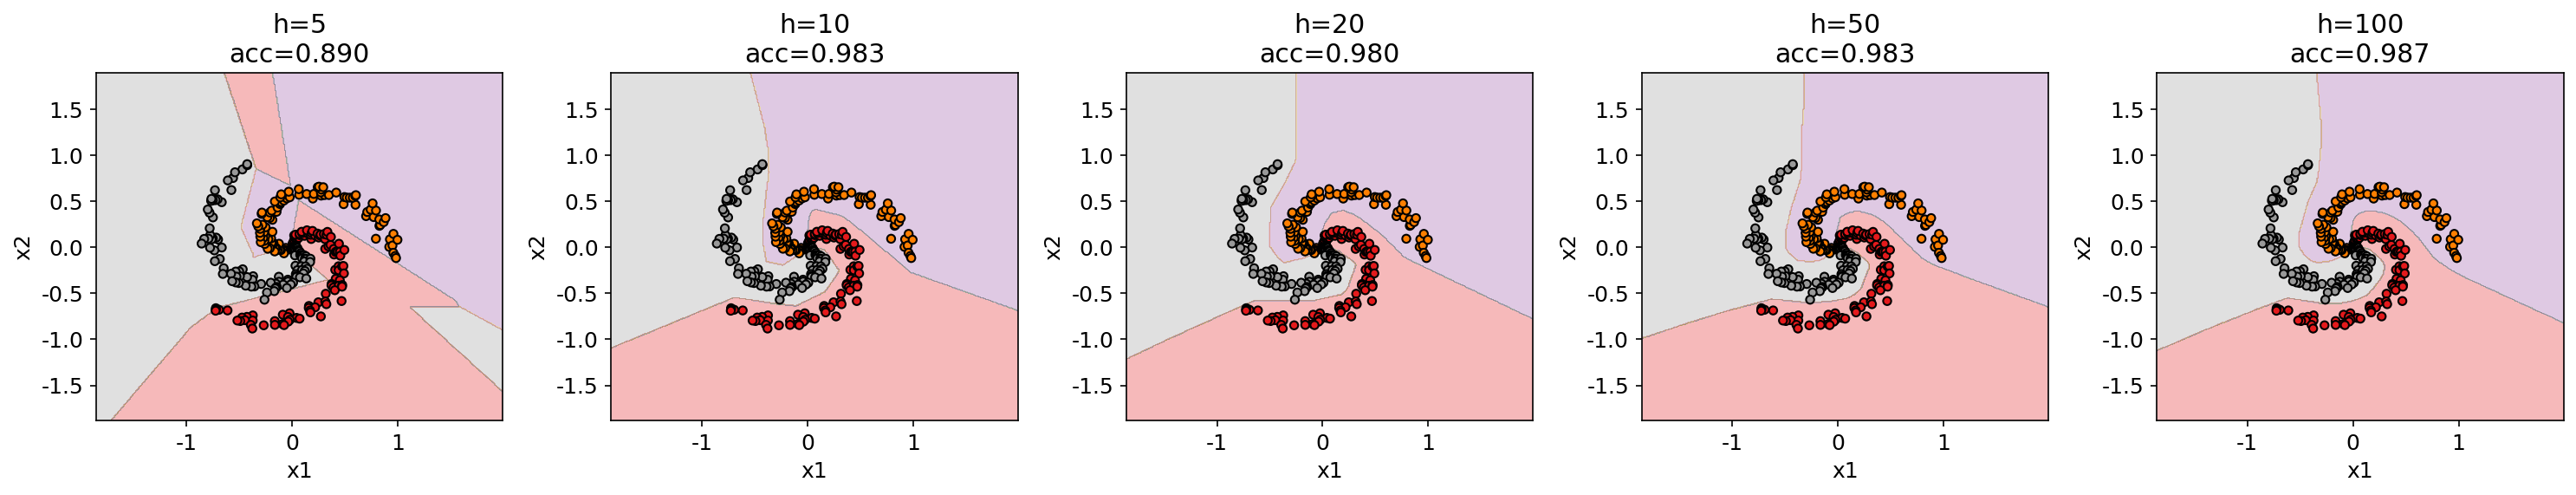

In [32]:
# Experiment with different hidden layer sizes
hidden_sizes = [5, 10, 20, 50, 100]
fig, axes = plt.subplots(1, len(hidden_sizes), figsize=(20, 4))

for i, h_size in enumerate(hidden_sizes):
    net_exp = TwoLayerNet(input_dim=2, hidden_dim=h_size, num_classes=3, reg=0.001)
    
    for epoch in range(1000):
        loss, probs, cache = net_exp.loss(X_train_sp, y_train_sp)
        grads = net_exp.backward(X_train_sp, y_train_sp, probs, cache)
        for param in net_exp.params:
            net_exp.params[param] -= 0.5 * grads[param]
    
    train_acc = np.mean(net_exp.predict(X_train_sp) == y_train_sp)
    plot_decision_boundary_nn(net_exp, X_train_sp, y_train_sp, axes[i], 
                              f'h={h_size}\nacc={train_acc:.3f}')

plt.tight_layout()
plt.savefig('hidden_size_effect.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization saved as hidden_size_effect.png")


### 实验 4：学习率的影响


Visualization saved as learning_rate_effect_nn.png


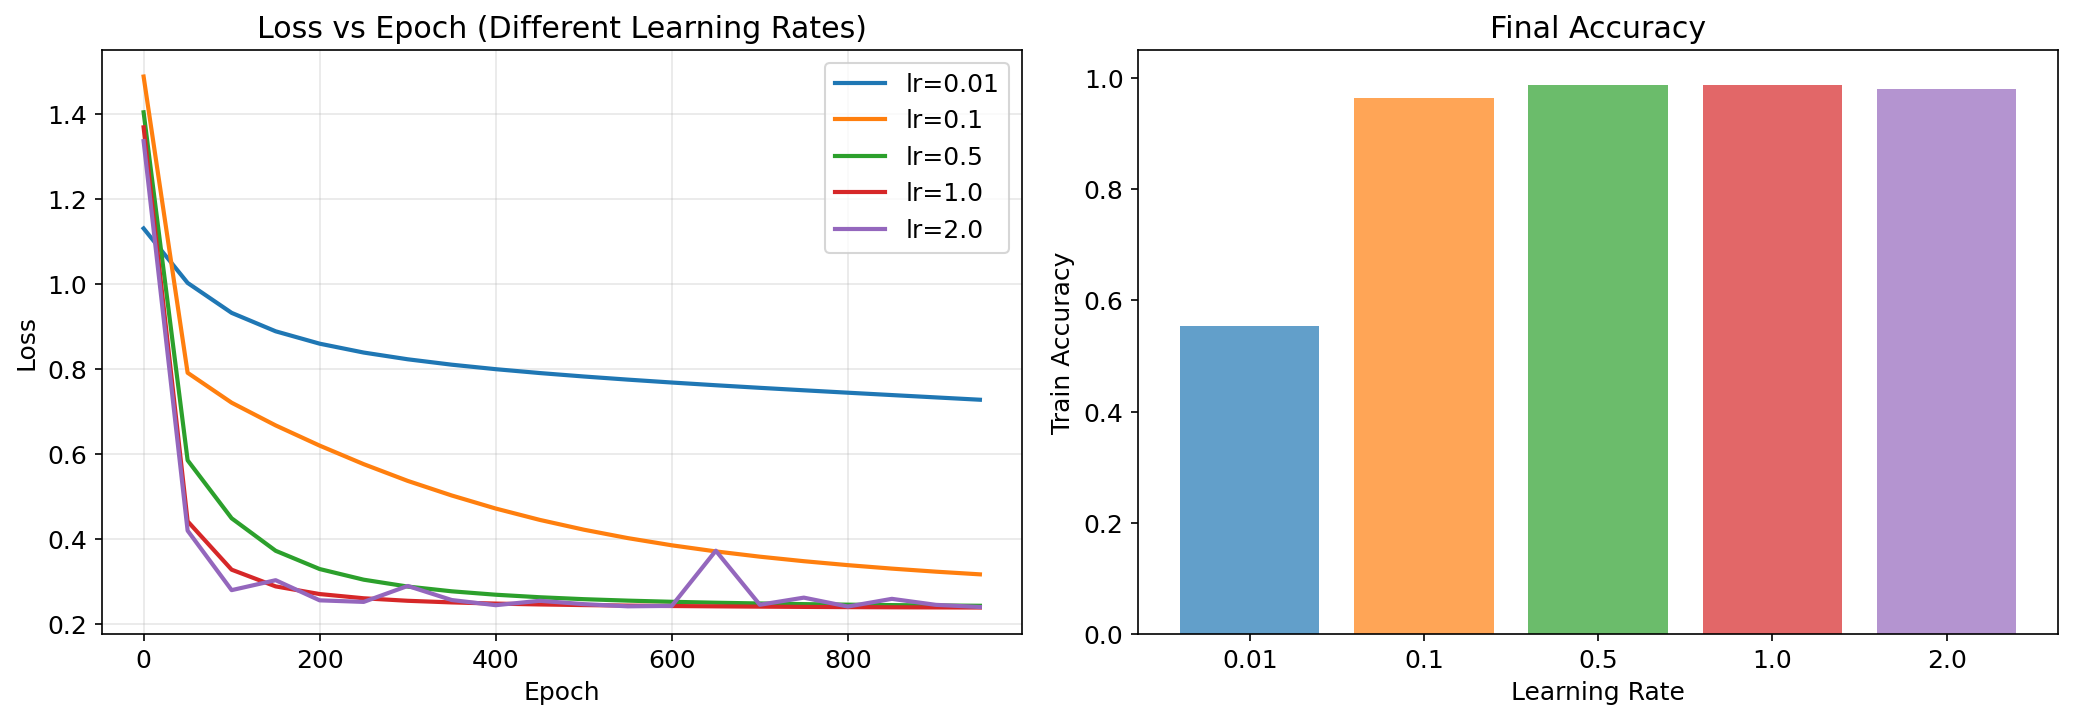

In [34]:
# Experiment with different learning rates
learning_rates = [0.01, 0.1, 0.5, 1.0, 2.0]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for lr in learning_rates:
    net_lr = TwoLayerNet(input_dim=2, hidden_dim=50, num_classes=3, reg=0.001)
    losses_lr = []
    
    for epoch in range(1000):
        loss, probs, cache = net_lr.loss(X_train_sp, y_train_sp)
        grads = net_lr.backward(X_train_sp, y_train_sp, probs, cache)
        for param in net_lr.params:
            net_lr.params[param] -= lr * grads[param]
        if epoch % 50 == 0:
            losses_lr.append(loss)
    
    axes[0].plot(range(0, 1000, 50), losses_lr, linewidth=2, label=f'lr={lr}')
    
    acc = np.mean(net_lr.predict(X_train_sp) == y_train_sp)
    axes[1].bar(str(lr), acc, alpha=0.7)

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss vs Epoch (Different Learning Rates)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Learning Rate')
axes[1].set_ylabel('Train Accuracy')
axes[1].set_title('Final Accuracy')
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('learning_rate_effect_nn.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization saved as learning_rate_effect_nn.png")


## 9. 梯度消失与梯度爆炸

### 9.1 问题分析

**梯度消失 (Vanishing Gradient):**
- 在深层网络中，梯度通过链式法则逐层相乘
- 如果每层梯度 < 1，梯度指数衰减
- Sigmoid/tanh 的最大梯度分别是 0.25 和 1，容易导致梯度消失

**梯度爆炸 (Exploding Gradient):**
- 如果每层梯度 > 1，梯度指数增长
- 参数更新过大，训练不稳定

### 9.2 解决方案

1. **ReLU 激活函数：** 正半区梯度为 1，缓解梯度消失
2. **批归一化 (Batch Normalization)：** 控制每层输入的分布
3. **残差连接 (Residual Connections)：** 梯度可以直接跳过层
4. **梯度裁剪 (Gradient Clipping)：** 限制梯度大小
5. **合理的权重初始化：** 如 He 初始化、Xavier 初始化


Visualization saved as vanishing_gradient.png


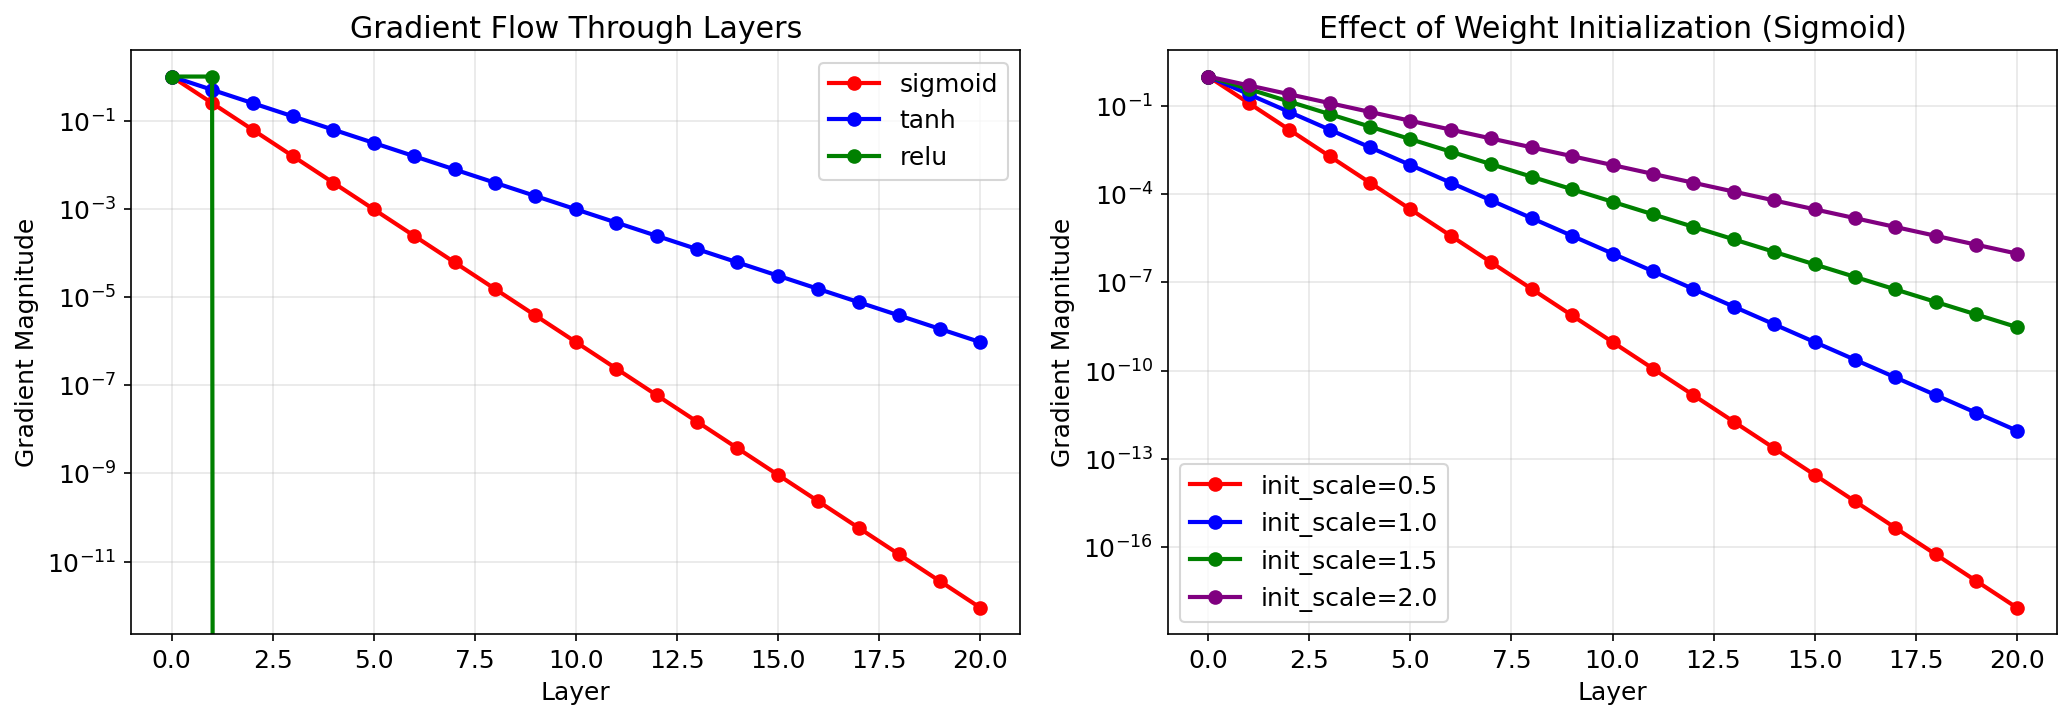

In [36]:
# Demonstrate vanishing gradient problem
# Simulate gradient through multiple layers
def simulate_gradient_flow(depth, activation_type, init_scale):
    """
    Simulate how gradients flow through a deep network
    """
    grad = 1.0
    grad_history = [grad]
    
    for i in range(depth):
        # Simulate forward activation
        if activation_type == 'sigmoid':
            # Sigmoid gradient: s*(1-s), max at s=0.5 => max gradient = 0.25
            local_grad = 0.25  # worst case for sigmoid
        elif activation_type == 'tanh':
            local_grad = 1.0 - 0.0**2  # max gradient = 1.0 at tanh=0
            local_grad = 0.5  # average
        elif activation_type == 'relu':
            local_grad = 1.0 if np.random.random() > 0.5 else 0
        
        # Also multiply by weight matrix scale
        grad = grad * local_grad * init_scale
        grad_history.append(grad)
    
    return grad_history

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Vanishing gradient comparison
depth = 20
for act, color in [('sigmoid', 'red'), ('tanh', 'blue'), ('relu', 'green')]:
    grads = simulate_gradient_flow(depth, act, init_scale=1.0)
    axes[0].plot(range(depth + 1), grads, 'o-', linewidth=2, label=act, color=color)

axes[0].set_xlabel('Layer')
axes[0].set_ylabel('Gradient Magnitude')
axes[0].set_title('Gradient Flow Through Layers')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

# Effect of weight initialization
for init_scale, color in [(0.5, 'red'), (1.0, 'blue'), (1.5, 'green'), (2.0, 'purple')]:
    grads = simulate_gradient_flow(depth, 'sigmoid', init_scale=init_scale)
    axes[1].plot(range(depth + 1), grads, 'o-', linewidth=2, 
                label=f'init_scale={init_scale}', color=color)

axes[1].set_xlabel('Layer')
axes[1].set_ylabel('Gradient Magnitude')
axes[1].set_title('Effect of Weight Initialization (Sigmoid)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_yscale('log')

plt.tight_layout()
plt.savefig('vanishing_gradient.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization saved as vanishing_gradient.png")


## 10. 权重初始化

### 10.1 为什么初始化重要

- **全零初始化：** 所有神经元学习相同特征（对称性问题）
- **太大：** 激活值过大，梯度爆炸
- **太小：** 激活值过小，梯度消失

### 10.2 常用初始化方法

**Xavier/Glorot 初始化 (适合 tanh):**
$$W \sim N(0, \frac{1}{\text{fan\_in}})$$

**He 初始化 (适合 ReLU):**
$$W \sim N(0, \frac{2}{\text{fan\_in}})$$

其中 fan_in 是输入维度，fan_out 是输出维度。

**直觉：** 希望每层的输出方差与输入方差相同，保持信号传播。


Visualization saved as initialization_comparison.png


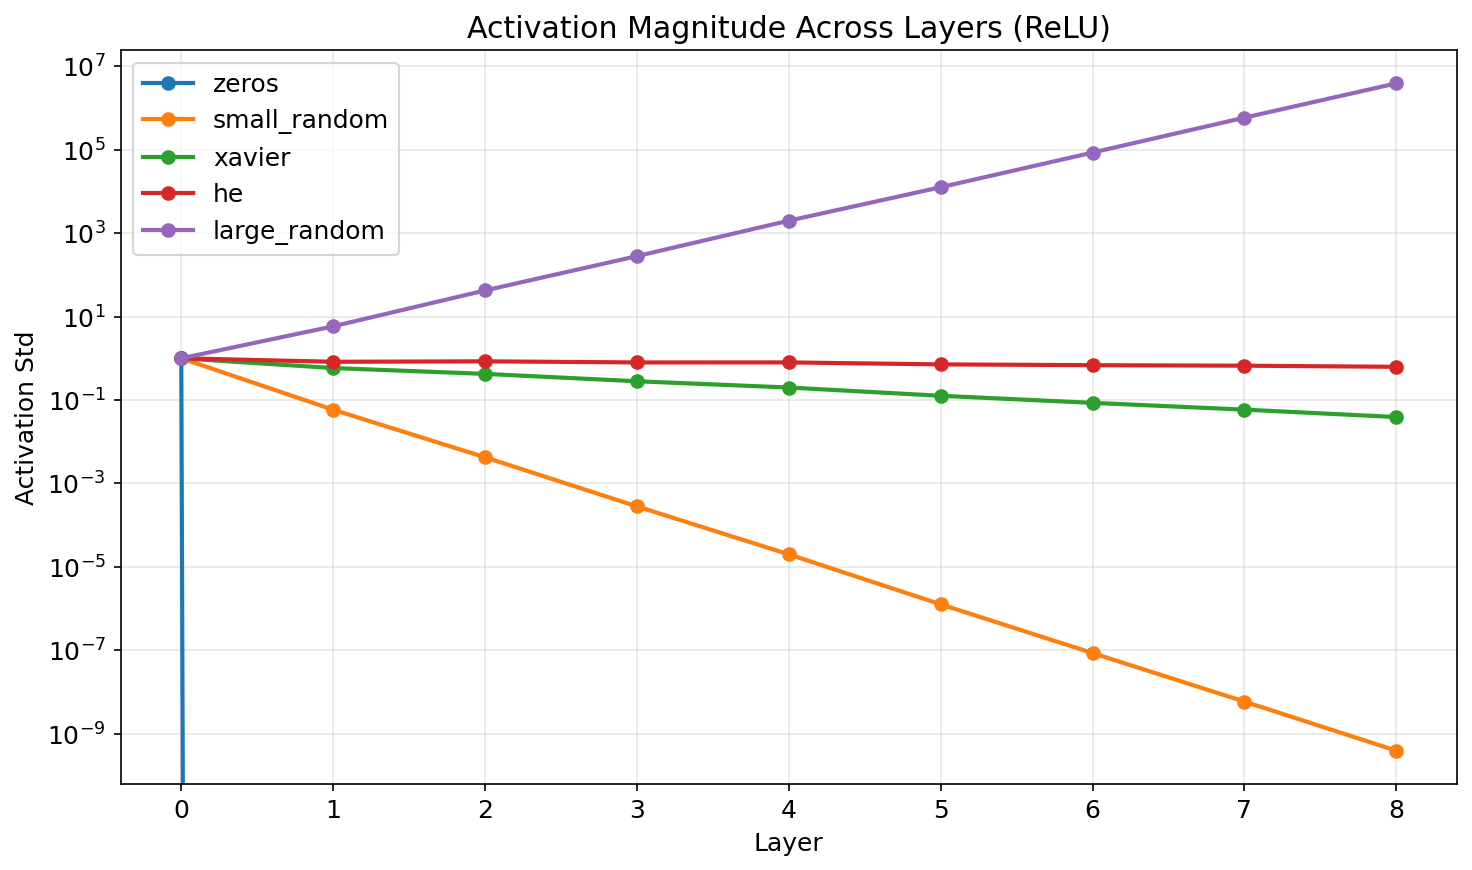

In [38]:
# Compare initialization methods
def compare_initializations(input_dim, hidden_dim, n_layers=5, n_samples=1000):
    """Compare different weight initialization strategies"""
    results = {}
    
    inits = {
        'zeros': lambda fan_in, fan_out: np.zeros((fan_in, fan_out)),
        'small_random': lambda fan_in, fan_out: np.random.randn(fan_in, fan_out) * 0.01,
        'xavier': lambda fan_in, fan_out: np.random.randn(fan_in, fan_out) * np.sqrt(1.0 / fan_in),
        'he': lambda fan_in, fan_out: np.random.randn(fan_in, fan_out) * np.sqrt(2.0 / fan_in),
        'large_random': lambda fan_in, fan_out: np.random.randn(fan_in, fan_out) * 1.0,
    }
    
    for name, init_fn in inits.items():
        np.random.seed(42)
        x = np.random.randn(n_samples, input_dim)
        
        activations = [np.std(x)]
        for layer in range(n_layers):
            W = init_fn(input_dim, hidden_dim)
            x = x @ W
            x = np.maximum(0, x)  # ReLU
            activations.append(np.std(x))
        
        results[name] = activations
    
    return results

results = compare_initializations(input_dim=100, hidden_dim=100, n_layers=8)

plt.figure(figsize=(10, 6))
for name, acts in results.items():
    plt.plot(range(len(acts)), acts, 'o-', linewidth=2, label=name)

plt.xlabel('Layer')
plt.ylabel('Activation Std')
plt.title('Activation Magnitude Across Layers (ReLU)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.tight_layout()
plt.savefig('initialization_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization saved as initialization_comparison.png")


## 11. 实验结果分析

### 关键发现

1. **非线性是关键：** 神经网络通过非线性激活函数可以学习复杂的非线性决策边界（如螺旋数据）

2. **隐藏层大小的影响：**
   - 太小：欠拟合，无法学习复杂模式
   - 适中：良好拟合
   - 太大：可能过拟合，需要更多正则化

3. **学习率的影响：**
   - 太小：收敛慢
   - 适中：快速稳定收敛
   - 太大：损失震荡或不收敛

4. **ReLU 优于 Sigmoid：** ReLU 梯度不消失，更适合深层网络

5. **权重初始化重要：** He 初始化适合 ReLU，Xavier 适合 tanh

### 反向传播总结

| 概念 | 作用 |
|------|------|
| 计算图 | 将复杂函数分解为简单操作 |
| 前向传播 | 从输入到输出计算值 |
| 反向传播 | 从输出到输入计算梯度 |
| 链式法则 | 合成函数的梯度分解 |
| 局部梯度 | 每个节点的导数 |
| 上游梯度 | 从后向前传递的梯度信号 |


## 12. 作业

### 作业 1：实现三层神经网络

**要求：**
1. 在 TwoLayerNet 基础上扩展为 ThreeLayerNet
2. 架构：input -> hidden1 (ReLU) -> hidden2 (ReLU) -> output (Softmax)
3. 实现完整的前向传播和反向传播
4. 进行梯度检验验证正确性
5. 在螺旋数据上训练并与两层网络对比

**提示：** 注意第二隐藏层的反向传播，ReLU 的梯度只在正区间非零

### 作业 2：实现不同的激活函数并比较

**要求：**
1. 实现 Leaky ReLU、ELU、GELU 激活函数及其梯度
2. 在深层网络（10层）中比较不同激活函数的梯度流
3. 分析哪种激活函数在深层网络中表现最好
4. 可视化各激活函数在不同层的激活值分布

**ELU 公式：** $f(x) = \begin{cases}x & x > 0 \\ \alpha(e^x - 1) & x \leq 0\end{cases}$

### 作业 3：实现批归一化 (Batch Normalization)

**要求：**
1. 实现批归一化层的前向和反向传播
2. 在深层网络中比较有/无批归一化时梯度流的变化
3. 分析批归一化如何帮助解决梯度消失问题

**前向公式：** $\hat{x} = \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}}$, $y = \gamma \hat{x} + \beta$

**提示：** 反向传播需要计算对 $\mu, \sigma^2, \gamma, \beta$ 和输入 $x$ 的梯度


## 13. 参考文献

1. **CS231n: Convolutional Neural Networks for Visual Recognition**, Stanford University
   - Lecture 4: Backpropagation and Neural Networks
   - https://cs231n.github.io/optimization-2/

2. **Rumelhart, D. E., Hinton, G. E., & Williams, R. J. (1986)**. Learning representations by back-propagating errors. Nature, 323(6088), 533-536.

3. **He, K., Zhang, X., Ren, S., & Sun, J. (2015)**. Delving Deep into Rectifiers: Surpassing Human-Level Performance on ImageNet Classification. ICCV 2015.

4. **Glorot, X. & Bengio, Y. (2010)**. Understanding the difficulty of training deep feedforward neural networks. AISTATS 2010.

5. **Nair, V. & Hinton, G. E. (2010)**. Rectified Linear Units Improve Restricted Boltzmann Machines. ICML 2010.

6. **Clevert, B. A., Unterthiner, T., & Hochreiter, S. (2015)**. Fast and Accurate Deep Network Learning by Exponential Linear Units (ELUs). ICLR 2016.

7. **Ioffe, S. & Szegedy, C. (2015)**. Batch Normalization: Accelerating Deep Network Training by Reducing Internal Covariate Shift. ICML 2015.

8. **Pascanu, R., Mikolov, T., & Bengio, Y. (2013)**. On the difficulty of training Recurrent Neural Networks. ICML 2013.

9. **Goodfellow, I., Bengio, Y., & Courville, A. (2016)**. Deep Learning. MIT Press. Chapter 6: Deep Feedforward Networks.

---

**本 notebook 总结：**
- 计算图将复杂函数分解为简单操作的图结构
- 链式法则是反向传播的数学基础
- 反向传播 = 前向传播 + 逆序遍历计算梯度
- 每个节点只需知道局部梯度，上游梯度乘以局部梯度传给下游
- 加法节点分配梯度，乘法节点交换梯度，max 节点路由梯度
- 神经网络通过非线性激活函数学习复杂决策边界
- ReLU 是最常用的激活函数，梯度不消失
- He 初始化适合 ReLU，Xavier 初始化适合 tanh
- 梯度消失和梯度爆炸是深层网络训练的主要挑战


---

## 参考代码实现

以下 GitHub 仓库提供了本节内容的完整代码实现，建议结合学习：

- **[jariasf/CS231n](https://github.com/jariasf/CS231n)** (486 stars): 反向传播作业解答
  - 仓库地址: https://github.com/jariasf/CS231n

- **[Yorko/stanford_cs231n_2019](https://github.com/Yorko/stanford_cs231n_2019)** (155 stars): 2019版作业解答与注释
  - 仓库地址: https://github.com/Yorko/stanford_cs231n_2019


> 标注说明: 以上仓库按热度排序，优先推荐 stars 最多的实现。

